# **Lab 3: Reconstruction from two views (knowing internal camera parameters)**

In this lab you will learn how to estimate the fundamental matrix that relates two images, corresponding to two different views of the same scene, given a set of correspondences between them. Also, you will learn how to triangulate the matching correspondences between two views of the same scene, by means of applying the Direct Linear Method (DLT). Then, you will compute the camera matrices of these images given the Fundamental Matrix and the Intrinsic Matrix, and will evaluate your triangulation method on these camera matrices by estimating the reprojection error in the triangulation. 

The following file combines some text cells (Markdown cells) and code cells. Some parts of the code need to be completed. All tasks you need to complete are marked in <span style='color:Green'> green.  </span>

In [1]:
from IPython.display import display, HTML
import numpy as np
from numpy import linalg as LA
import cv2
import math
import sys
import random
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['figure.figsize'] = (19, 10)
from operator import itemgetter
from plotly import graph_objects as go
import copy
from tqdm import tqdm
from multiprocessing import Pool
import numpy as np
from time import time 
from functools import partial

import utils
from utils import homogeneous2euclidean, euclidean2homogeneous, projective2img, img2projective

np.set_printoptions(precision=3)

## **1. Estimation of the fundamental matrix**

### **1.1 Normalized 8-point algorithm**

The first task is to create the function that estimates the fundamental matrix given a set of point correspondences between a pair of images.

<span style='color:Green'> - Complete the function "fundamental_matrix" below.  </span>

In [2]:
def fundamental_matrix(points1, points2):

    def _to_homogeneous(pts):
        pts = np.asarray(pts, dtype=np.float64)

        if pts.shape[0] in (2, 3) and pts.shape[1] not in (2, 3):
            # likely (2,N) or (3,N)
            pts = pts.T

        if pts.shape[1] == 2:
            ones = np.ones((pts.shape[0], 1), dtype=np.float64)
            pts_h = np.hstack([pts, ones])
            return pts_h

        if pts.shape[1] == 3:
            return pts

    def _normalize_points(pts_h):
        """
        Hartley-style normalization:
        - Translate so centroid is at origin
        - Scale so mean squared distance to origin is 1 (as stated in the slides)
        Returns:
            pts_n: normalized points (N,3)
            H: normalization transform (3,3) such that pts_n ~ H @ pts_h^T
        """
        pts_h = np.asarray(pts_h, dtype=np.float64)

        # Dehomogenize safely for centroid/scale computation
        w = pts_h[:, 2:3]
        w_safe = np.where(np.abs(w) < 1e-12, 1e-12, w)
        pts_e = pts_h[:, 0:2] / w_safe  # (N,2)

        centroid = np.mean(pts_e, axis=0)  # (cx, cy)

        d = pts_e - centroid  # (N,2)
        msd = np.mean(np.sum(d**2, axis=1))  # mean squared distance

        if msd < 1e-12:
            s = 1.0
        else:
            s = 1.0 / np.sqrt(msd)

        cx, cy = centroid
        H = np.array([
            [s, 0.0, -s * cx],
            [0.0, s, -s * cy],
            [0.0, 0.0, 1.0]
        ], dtype=np.float64)

        pts_n = (H @ pts_h.T).T  # (N,3)
        return pts_n, H


    # 0. Convert to homogeneous if necessary
    p1 = _to_homogeneous(points1)
    p2 = _to_homogeneous(points2)

    # 1. Normalize points
    q1, H1 = _normalize_points(p1)
    q2, H2 = _normalize_points(p2)

    # Dehomogenize normalized points for W construction
    q1 = q1 / np.where(np.abs(q1[:, 2:3]) < 1e-12, 1e-12, q1[:, 2:3])
    q2 = q2 / np.where(np.abs(q2[:, 2:3]) < 1e-12, 1e-12, q2[:, 2:3])

    u  = q1[:, 0]
    v  = q1[:, 1]
    up = q2[:, 0]
    vp = q2[:, 1]

    # 2. Build W (Nx9)
    #    row = [u'*u, u'*v, u', v'*u, v'*v, v', u, v, 1]
    W = np.column_stack([
        up * u,  up * v,  up,
        vp * u,  vp * v,  vp,
        u,       v,       np.ones_like(u)
    ])

    # 3. SVD(W) -> f is last column of V
    Uw, Sw, Vtw = np.linalg.svd(W, full_matrices=True)
    f = Vtw[-1, :]  # last row of V^T = last column of V

    # 4. Compose F_rank3 (3x3)
    F_rank3 = f.reshape(3, 3)

    # 5-7. Enforce rank-2 constraint on F (SVD, zero last singular value)
    Uf, Sf, Vtf = np.linalg.svd(F_rank3)
    Sf[2] = 0.0
    F_rank2 = Uf @ np.diag(Sf) @ Vtf

    # 8. De-normalize: F = H2^T * F_rank2 * H1
    F = H2.T @ F_rank2 @ H1

    return F


<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

**Function: `_to_homogeneous(pts)`**  
- If the points come transposed (for example, 2×N instead of N×2), it transposes them to N×2 / N×3.
- If the points are Euclidean (only x and y), it appends a third coordinate equal to 1 so they become homogeneous.
- If they are already homogeneous, it returns them directly.

**Function: `_normalize_points(pts_h)`**  
- It computes the centroid (average position) of the points.
- It recenters the points so the centroid becomes the origin.
- It rescales them so their overall spread is well-conditioned.
- It returns the normalized points and the transform used, so we can undo it later.

---

0. **Convert inputs to homogeneous coordinates**  
   The input correspondences `points1` and `points2` are converted to a homogeneous representation so that both sets follow the same coordinate format throughout the algorithm.

1. **Normalize both point sets**  
   Each set of points (image 1 and image 2) is normalized independently to reduce numerical issues when solving the linear system later. The normalization transforms are saved because they are needed at the end.

2. **Build the linear system matrix `W`**  
   Using the normalized correspondences, the code creates one linear constraint per correspondence and stacks them all into a matrix `W`. This is the matrix that encodes the 8-point constraints.

3. **Solve using SVD and extract the best solution**  
   The code computes the SVD of `W`. The solution that best satisfies the constraints (in a least-squares sense) is the singular vector associated with the smallest singular value. That vector is extracted as `f`.

4. **Reshape the solution into a 3×3 matrix**  
   The vector `f` has 9 elements, so it is reshaped into a 3×3 matrix. This is the initial estimated fundamental matrix, but it may not yet be physically valid.

5-7. **Enforce the rank-2 constraint**  
   A valid fundamental matrix must have rank 2. To enforce this:
   - The code computes the SVD of the estimated matrix,
   - forces the smallest singular value to be zero,
   - and reconstructs the matrix again.  
   This produces a corrected estimate that satisfies the rank condition.

8. **De-normalize back to the original coordinate system**  
   Since the estimation was done using normalized points, the matrix is transformed back so that it correctly applies to the original input coordinates.


In order to check that the completed function works properly you may use this code which is a toy example where we know the ground truth image.

<span style='color:Green'> - Complete the expression of the ground truth fundamental matrix.  </span>

In [3]:
# Two camera matrices for testing purposes

#1. Define the first camera matrix, P1 = I
P1 = np.zeros((3,4))
P1[0,0]=P1[1,1]=P1[2,2]=1 

#2. Define the second camera matrix, P2 = [R ∣ t]
angle = 15
theta = np.radians(angle)
c = np.cos(theta)
s = np.sin(theta)
R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
t = np.array([[.3, .1, .2]])
P2 = np.concatenate((R, t.T), axis=1)

#3. Generate some random 3D points 
n = 8
rand = np.random.uniform(0,1,n)
rand = rand.reshape((1, n))
rand2 = np.random.uniform(0,1,2*n)
rand2 = rand2.reshape((2, n))
ones = np.ones((1,n))
X = np.concatenate((rand2, 3*rand, ones), axis=0)

#4. Project the points into the two cameras (There are no Intrinsic parameters, so K1=K2=I)
x1_test = P1 @ X
x2_test = P2 @ X

#5. Estimate fundamental matrix (you need to create this function)
F_es = fundamental_matrix(x1_test, x2_test)

#6. Ground truth fundamental matrix is F = K2^-T E K1^-1, but K1=K2=I here
# So, F = I E I = E = [t]_x R
tx, ty, tz = float(t[0,0]), float(t[0,1]), float(t[0,2])
t_x = np.array([
    [0.0, -tz,  ty],
    [tz,  0.0, -tx],
    [-ty,  tx, 0.0]
])
F_gt = t_x @ R

#7. Evaluation: these two matrices should be very similar
F_gt = np.sign(F_gt[0,0])*F_gt / LA.norm(F_gt)
F_es = np.sign(F_es[0,0])*F_es / LA.norm(F_es)
print(F_gt)
print(F_es)
print(LA.norm(F_gt-F_es))

[[ 0.098  0.365 -0.189]
 [-0.365  0.098  0.567]
 [ 0.036 -0.597 -0.   ]]
[[ 9.782e-02  3.651e-01 -1.890e-01]
 [-3.651e-01  9.782e-02  5.669e-01]
 [ 3.581e-02 -5.965e-01 -3.456e-16]]
6.737609893281845e-15


<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

1. The first camera matrix is set to the canonical form **P1 = [I | 0]**, meaning no rotation and no translation..

2. The second camera is defined as **P2 = [R | t]**, where **R** is a rotation of **15° around the Z axis**, and **t** is a translation vector that places camera 2 at a different position.

3. We generate **n = 8** random 3D points in homogeneous coordinates **X (4×8)**. The “8” is chosen because the 8-point algorithm needs at least 8 correspondences.

4. The projections are computed as **x1 = P1·X** and **x2 = P2·X**. Since **P1** and **P2** do not include a **K** matrix, this experiment assumes **K1 = K2 = I** (normalized camera model).

5.  Using the projected correspondences **(x1_test, x2_test)**, we estimate the fundamental matrix with the previously implemented function: **F_es = fundamental_matrix(x1_test, x2_test)**.

6. In general, **F = K2^{-T} E K1^{-1}** and **E = [t]_× R**. Because here **K1 = K2 = I**, we get **F = E = [t]_× R**.

7. Both matrices are then compared. If the implementation is correct, **F_es** and **F_gt** should be **equal up to small numerical differences**, so **‖F_gt − F_es‖** should be close to 0.


### **1.2 Robust estimation of the fundamental matrix**

The goal of this section is to estimate the fundamental matrix in a practical situation where the image correspondences contain outliers. For that you will have to write the code of the robust version of the previous algorithm.

We will start by computing and visualizing the image matches.

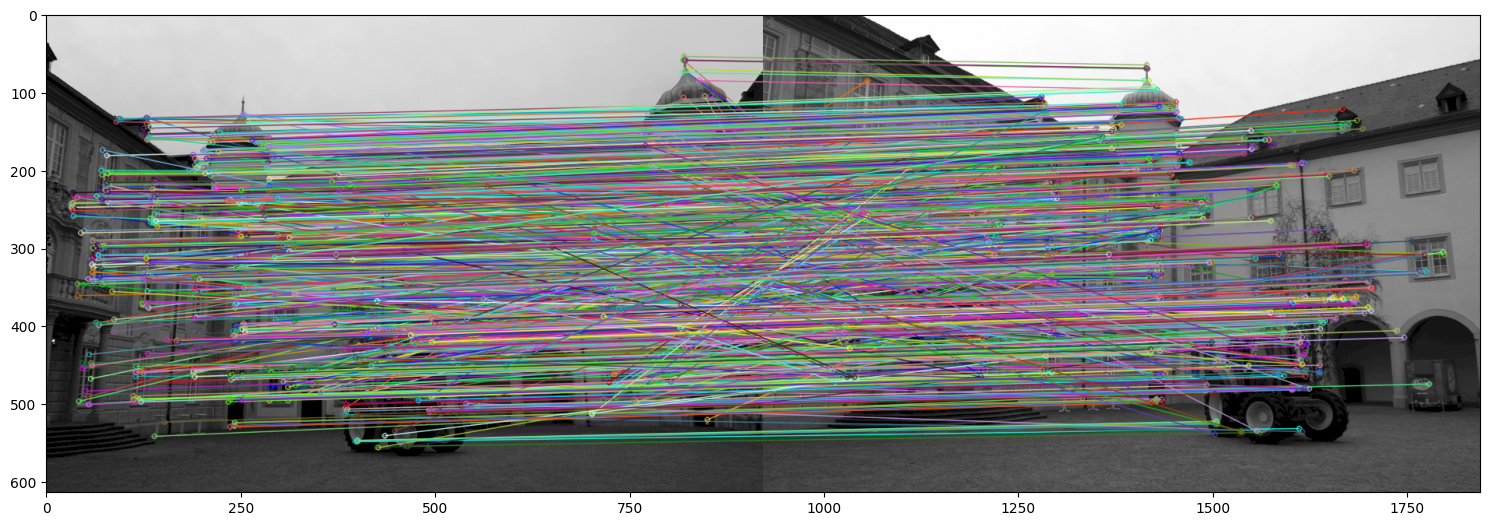

In [4]:
# Compute inage correspondences #

# Read images
img1 = cv2.imread('Data/0000_s.png',cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('Data/0001_s.png',cv2.IMREAD_GRAYSCALE)

# Initiate ORB detector
orb = cv2.ORB_create(3000)
# find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(img1,None)
kp2, des2 = orb.detectAndCompute(img2,None)

# Keypoint matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1,des2)

# Show "good" matches
img_12 = cv2.drawMatches(img1,kp1,img2,kp2,matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img_12)
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(18.5, 10.5)
plt.show()

<span style='color:Green'> - Write the function Ransac_fundamental_matrix that embeds in a RANSAC procedure the previous DLT algorithm for estimating the fundamental matrix. You may use the provided RANSAC function in lab 2 as a starting point.  </span>

Note: In order not to end up, eventually, in an infinite loop, it is recommended to set, at each iteration, the maximum number of iterarions to the maximum between a predefined maximum number of iterations by the user and the automatically estimated max. number of iterarions. The estimated number of iterations ensures we pick, with a probability of 0.99, an initial set of correspondences with no outliers.

In [5]:
def Ransac_fundamental_matrix(points1, points2, th, max_it_0):
    """
    Args:
        points1: points in image 1
        points2: points in image 2
        th: threshold on Sampson error 
        max_it_0: user predefined number of iterations 

    Returns:
        F: (3,3) Fundamental matrix
        inliers: list of int indices of inlier correspondences
    """

    def _to_3xN(pts):
        pts = np.asarray(pts, dtype=np.float64)
        if pts.ndim != 2:
            raise ValueError("points must be a 2D array")

        # If it's 2xN or 3xN, keep; if it's Nx2 or Nx3, transpose
        if pts.shape[0] in (2, 3) and pts.shape[1] not in (2, 3):
            # 2xN or 3xN
            pass
        else:
            # likely Nx2 or Nx3
            pts = pts.T

        if pts.shape[0] == 2:
            pts = np.vstack([pts, np.ones((1, pts.shape[1]), dtype=np.float64)])
        elif pts.shape[0] != 3:
            raise ValueError("points must be (2,N)/(3,N) or (N,2)/(N,3)")

        return pts  

    def _sampson_error(F, x1_3xN, x2_3xN, eps=1e-12):
        """
        Sampson error (PDF):
            (x2^T F x1)^2 / ( (Fx1)_1^2 + (Fx1)_2^2 + (F^T x2)_1^2 + (F^T x2)_2^2 )
        Returns: (N,) array
        """
        Fx1 = F @ x1_3xN          # 3xN
        Ftx2 = F.T @ x2_3xN       # 3xN
        x2tFx1 = np.sum(x2_3xN * Fx1, axis=0)  # (N,)

        denom = Fx1[0, :]**2 + Fx1[1, :]**2 + Ftx2[0, :]**2 + Ftx2[1, :]**2
        denom = np.maximum(denom, eps)

        return (x2tFx1**2) / denom

    # 1.Prepare points as 3xN 
    x1 = _to_3xN(points1)
    x2 = _to_3xN(points2)

    if x1.shape[1] != x2.shape[1]:
        raise ValueError("points1 and points2 must have same number of correspondences")

    N = x1.shape[1]
    if N < 8:
        raise ValueError("Need at least 8 correspondences")

    # 2.RANSAC params 
    s = 8
    p_success = 0.99
    th = float(th)

    rng = np.random.default_rng()

    best_F = None
    best_inliers_idx = np.array([], dtype=int)
    best_count = 0

    it = 0
    max_it = int(max_it_0)

    # 3.RANSAC loop 
    while it < max_it:
        idx = rng.choice(N, size=s, replace=False)

        try:
            F_cand = fundamental_matrix(x1[:, idx].T, x2[:, idx].T)  # pass as Nx3 (8x3)
        except Exception:
            it += 1
            continue

        # Compute Sampson error for all correspondences
        err = _sampson_error(F_cand, x1, x2)

        inliers_idx = np.where(err < th)[0]
        count = int(inliers_idx.size)

        if count > best_count:
            best_count = count
            best_inliers_idx = inliers_idx
            best_F = F_cand

            # Update estimated iterations (ensure 0.99 prob. of all-inlier sample)
            w = best_count / float(N)
            w = np.clip(w, 0.0, 1.0)

            if w >= 1.0 - 1e-12:
                N_est = 1.0
            else:
                denom = 1.0 - (w ** s)
                denom = np.clip(denom, 1e-12, 1.0 - 1e-12)
                N_est = np.log(1.0 - p_success) / np.log(denom)
                if not np.isfinite(N_est):
                    N_est = float(max_it_0)

            # maximum between user max and estimated max
            max_it = int(np.ceil(max(float(max_it_0), float(N_est))))

            # Safety cap to avoid absurd iteration counts 
            max_it = min(max_it, 200000)

        it += 1

    # 4.Refit with best inliers 
    if best_F is None or best_count < 8:
        F_all = fundamental_matrix(x1.T, x2.T)
        err_all = _sampson_error(F_all, x1, x2)
        inl_all = np.where(err_all < th)[0].astype(int).tolist()
        return F_all, inl_all

    # 5.Refine F with all inliers and recompute inliers once
    F_ref = fundamental_matrix(x1[:, best_inliers_idx].T, x2[:, best_inliers_idx].T)
    err_ref = _sampson_error(F_ref, x1, x2)
    inliers_ref = np.where(err_ref < th)[0].astype(int)

    return F_ref, inliers_ref.tolist()


<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

**Function: `_to_3xN(pts)`**
  - If points are Euclidean `(2, ·)`, it appends a row of ones to make them homogeneous `(3, ·)`.
  - Ensures the output is always **3×N**.

**Function: `_sampson_error(F, x1_3xN, x2_3xN, eps=1e-12)`**
  - **Purpose:** Compute the **Sampson error** for every correspondence (a first-order approximation of geometric reprojection error).
  - Uses `eps` to avoid division by zero.

---

1. **Data preparation**
- Convert `points1` and `points2` to **3×N homogeneous** format using `_to_3xN`.
- Validate:
  - Both sets contain the same number of correspondences.
  - At least **8** matches exist (minimum for the 8-point algorithm).


2. **RANSAC initialization**
- Set RANSAC parameters:
  - `s = 8` (minimal sample size)
  - `p_success = 0.99` (desired probability of sampling an outlier-free set)
  - `max_it = max_it_0` (initial / user-defined maximum iterations)
- Initialize the best model trackers:
  - `best_F`, `best_inliers_idx`, `best_count`

3. **RANSAC main loop**  
   For each iteration:

   1. **Randomly sample** 8 correspondences (without replacement).
   2. Estimate `F_cand` using `fundamental_matrix(...)` on the sampled points.
   3. Compute Sampson error for **all** correspondences via `_sampson_error`.
   4. Mark **inliers** where `err < th` and store their integer indices.
   5. If the number of inliers improves:
      - Update the best model (`best_*`).
      - Estimate the required number of iterations to reach probability 0.99
      - Update `max_it` as:  
        `max_it = max(max_it_0, N_est)` (plus an optional safety cap).


4. **Final refinement**
- If no valid model is found (e.g., `< 8` inliers), fall back to estimating `F` from all points.
- Otherwise:
  - Re-estimate `F_ref` using **all inliers** from the best hypothesis.
  - Recompute inliers once more using `F_ref`.
- Return:
  - `F_ref`
  - A **list of integer indices** for inlier correspondences


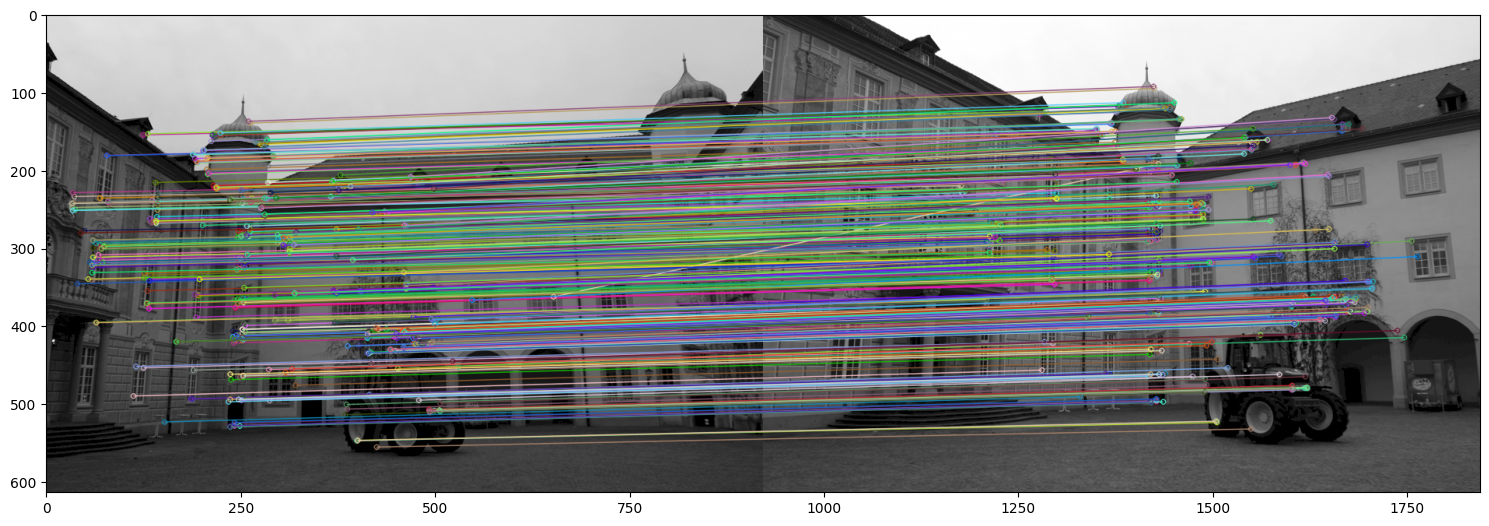

In [6]:
# Robust estimation of the fundamental matrix #
points1 = []
points2 = []
for m in matches:
    points1.append([kp1[m.queryIdx].pt[0], kp1[m.queryIdx].pt[1], 1])
    points2.append([kp2[m.trainIdx].pt[0], kp2[m.trainIdx].pt[1], 1])
    
points1 = np.asarray(points1)
points1 = points1.T
points2 = np.asarray(points2)
points2 = points2.T

F, indices_inlier_matches = Ransac_fundamental_matrix(points1, points2, 1, 5000)
inlier_matches = itemgetter(*indices_inlier_matches)(matches)

img_12 = cv2.drawMatches(img1,kp1,img2,kp2,inlier_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img_12)
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(18.5, 10.5)
plt.show()

### **1.3 Epipolar lines**

Now the fundamental matrix has been estimated we are going to display some points and their corresponding epipolar lines.

<span style='color:Green'> - Complete the code that computes the epipolar lines in both images.  </span>

#### Explanation

**Theory:** Points from image 1 represent a line in projective geometry that are seen as a single point from image 1 camera position. However, assuming that these points are visible from image 2, we can project the points from image 1 to image 2 with the fundamental matrix. So with no information on where the point should lie in image 2, what the camera from image 2 sees is the line that describes the point from image 1 projected into image 2. This line is the epipolar line, and is therefore obtained with just a matrix multiplication between the fundamental matrix and the point we select.  

**Implementation notes:** For image 1 we transpose the fundamental matrix as the non-transposed matrix describes the projection from image 1 to image 2, and by transposing we can get the opposite projection, as stated in the theory from class.

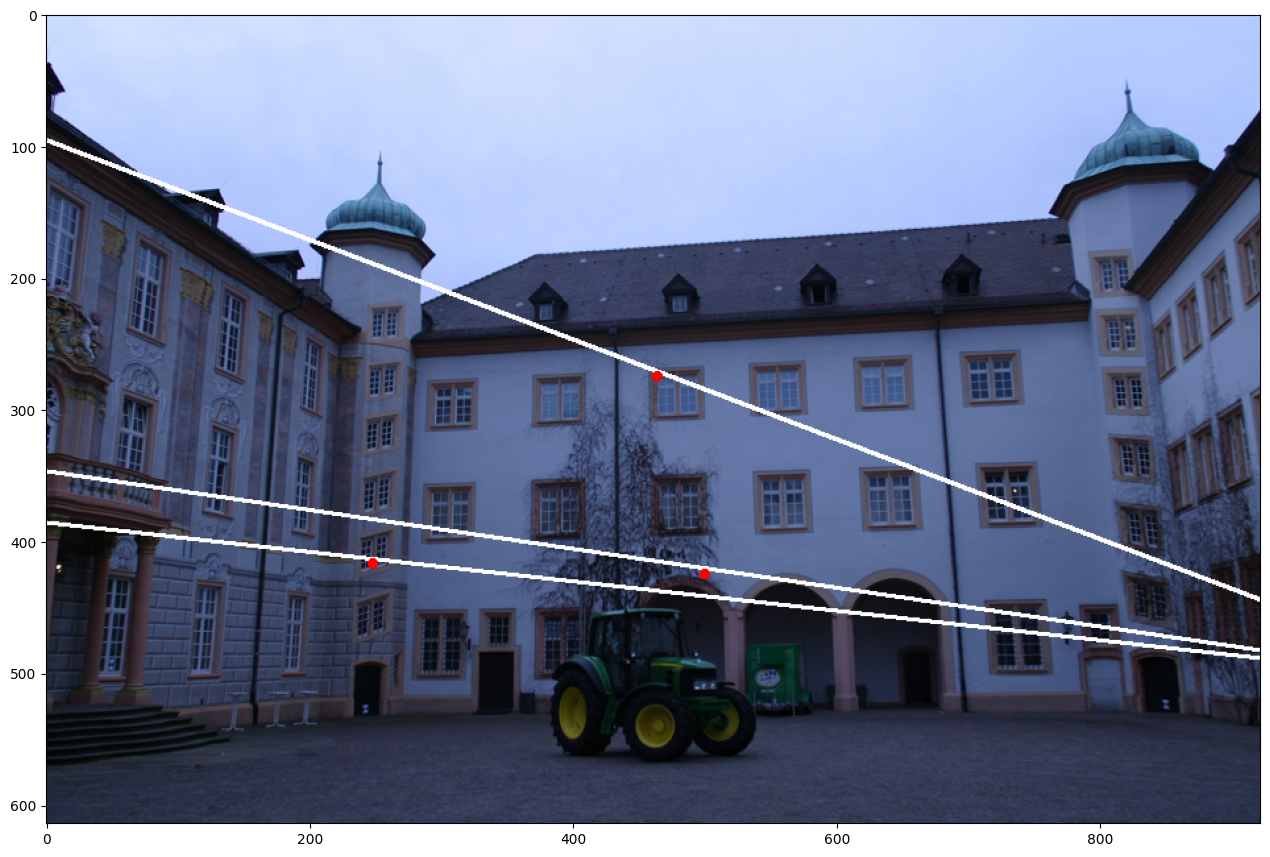

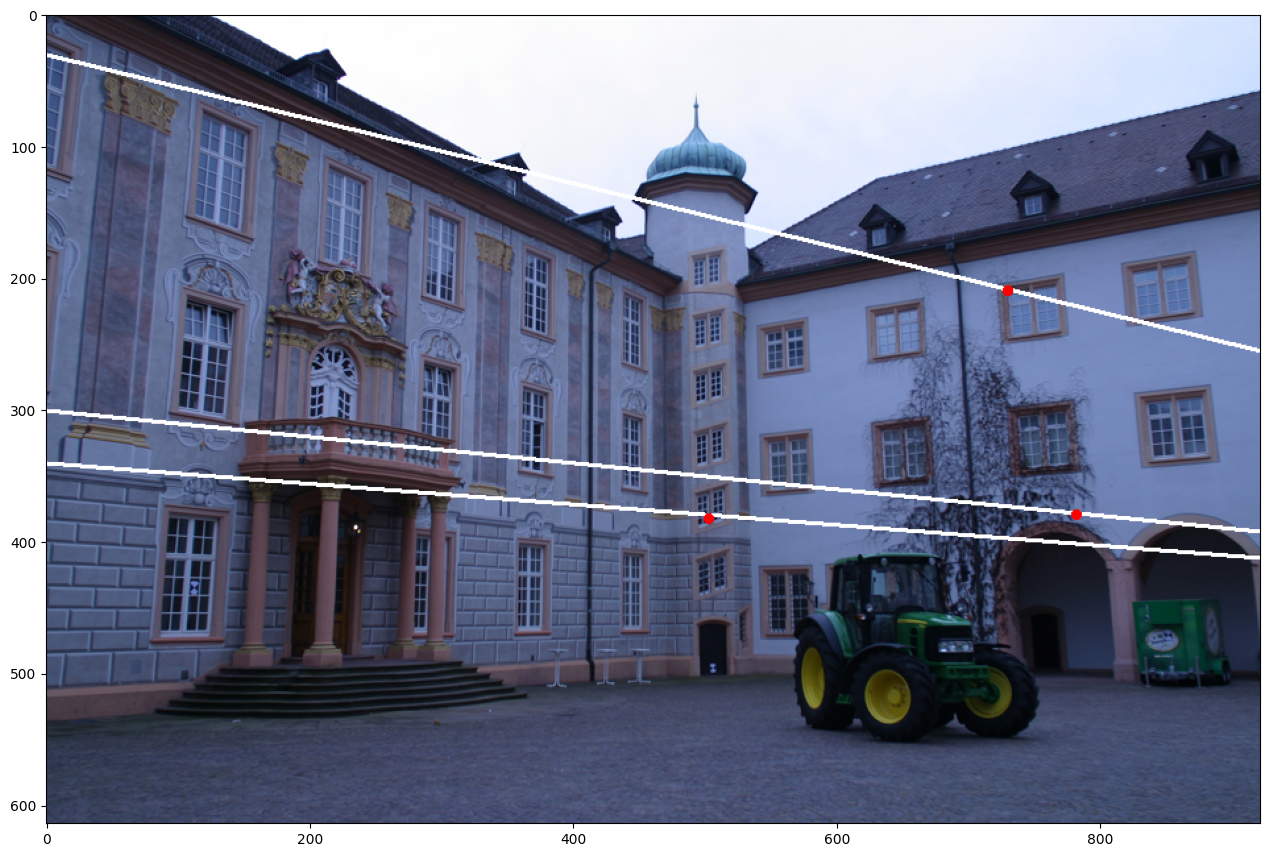

In [7]:
l2 = F @ points1 # epipolar lines in image 2 (complete) 
l1 = F.T @ points2 # epipolar lines in image 1 (complete) 

# choose three random indices
N = len(indices_inlier_matches)
indices = random.sample(range(1, N), 3)

m1 = indices_inlier_matches[indices[0]]
m2 = indices_inlier_matches[indices[1]]
m3 = indices_inlier_matches[indices[2]]

from PIL import Image, ImageDraw
from utils import line_draw, plot_img

img_path = "./Data/0000_s.png"
I = Image.open(img_path)
size = I.size
canv = ImageDraw.Draw(I)
line_draw(l1[:,m1], canv, size)
line_draw(l1[:,m2], canv, size)
line_draw(l1[:,m3], canv, size)
canv.ellipse((round(points1[0,m1]), round(points1[1,m1]), round(points1[0,m1])+7, round(points1[1,m1])+7), fill = 'red', outline ='red')
canv.ellipse((round(points1[0,m2]), round(points1[1,m2]), round(points1[0,m2])+7, round(points1[1,m2])+7), fill = 'red', outline ='red')
canv.ellipse((round(points1[0,m3]), round(points1[1,m3]), round(points1[0,m3])+7, round(points1[1,m3])+7), fill = 'red', outline ='red')
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(18.5, 10.5)
plot_img(I)

img_path = "./Data/0001_s.png"
I2 = Image.open(img_path)
size = I2.size
canv2 = ImageDraw.Draw(I2)
line_draw(l2[:,m1], canv2, size)
line_draw(l2[:,m2], canv2, size)
line_draw(l2[:,m3], canv2, size)
canv2.ellipse((round(points2[0,m1]), round(points2[1,m1]), round(points2[0,m1])+7, round(points2[1,m1])+7), fill = 'red', outline ='red')
canv2.ellipse((round(points2[0,m2]), round(points2[1,m2]), round(points2[0,m2])+7, round(points2[1,m2])+7), fill = 'red', outline ='red')
canv2.ellipse((round(points2[0,m3]), round(points2[1,m3]), round(points2[0,m3])+7, round(points2[1,m3])+7), fill = 'red', outline ='red')
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(18.5, 10.5)
plot_img(I2)


## **2. Triangulation with the DLT method**

The first task is to implement the DLT method that will compute the 3D points corresponding to the matches of two images whose camera matrices are known. [See derivation of DLT here](https://www.cs.cmu.edu/~16385/s17/Slides/11.4_Triangulation.pdf)

![image](https://user-images.githubusercontent.com/8356912/151347636-c3332917-a7da-402e-9eb6-f39beb91591a.png)


<span style='color:Green'> - Create the function triangulate(x1, x2, P1, P2, imsize) that performs a triangulation with the homogeneous algebraic method (DLT)  </span>

The entries are (x1, x2, P1, P2, imsize), where:
- x1: array of shape (3, `n_points`), containing matching points in projective coordinates from Camera 1 reference frame 
- x2: array of shape (3, `n_points`), containing matching points in projective coordinates from Camera 2 reference frame.
- P1: Camera 1 matrix of shape (3,4)
- P2: Camera 2 matrix of shape (3,4)
- imsize: Iterable with shape (2,) with the image size

The function should return:
- X: array of shape (4, `n_points`), containing the Homogenous Coordinates of the points in 3D space.  

Test the triangulate function: use this code to validate that the function triangulate works properly

HINT: check numpy.linalg.svd

#### Explanation

**Theory:** With two views of the same scene, a point of the scene appearing in both images are in different positions between each image. That mismatch allows us to triangulate the location in the 3D space. This can be achieved by using the camera matrices P, which map a point in 3D space to the coordinates of a given image. So in theory, by taking the same point in both images, we can build a system of equations that would give the 3D point **X**. However, we must assume that in reality there is noise when taking measures, and therefore this system of equations may not have a solution. That is why the triangulation problem is considered as a minimization problem, in which we get the 3D point in space that approximates better to the corresponding points in both images.  

**Implementation notes:** To implement this, we first had to ensure that the input points had a 1 as the last coordinate, as the method failed otherwise and we saw no homogenous normalization to (x, y, 1) in the following test. For the normalisation with matrix H, we used imsize assuming it had the shape (H, W), and therefore the first component corresponds to the y axis and the second to the x axis. We also tried to take advantage of numpy's vectorization by stacking the A matrices and computing the SVD of each of them with a single numpy's svd call. 

In [8]:
# Write here the method for DLT triangulation
def triangulate(x1, x2, P1, P2, imsize) -> np.ndarray:
    assert P1.shape == (3,4) == P2.shape
    assert x1.shape == x2.shape and x1.shape[0] == 3
    '''
    Your implementation here
    '''
    # DLT approach
    # Step 0: Ensure homogeneous coordinates x1 and x2 have form of [x, y, 1]
    x1 = x1 / x1[2]
    x2 = x2 / x2[2]
    
    # Step 1: Normalize coordinates with matrix H
    H = np.array([
        [2 / imsize[1],      0,        -1],
        [     0,        2 / imsize[0], -1],
        [     0,             0,         1]
    ])
    x1_norm = H @ x1
    x2_norm = H @ x2
    P1_norm = H @ P1
    P2_norm = H @ P2

    # Step 2: Compute matrix A
    A = np.stack([
        x1_norm[0:1].T @ P1_norm[2:3] - P1_norm[0:1],
        x1_norm[1:2].T @ P1_norm[2:3] - P1_norm[1:2],
        x2_norm[0:1].T @ P2_norm[2:3] - P2_norm[0:1],
        x2_norm[1:2].T @ P2_norm[2:3] - P2_norm[1:2],
    ], axis=0).transpose(1, 0, 2) # Shape: 4 x n_points x 4 -> n_points x 4 x 4

    # Step 3: SVD decomposition to extract right null-vector (last column of V, last row of V transposed)
    _, _, Vh = LA.svd(A) 
    X_trian = Vh[:, -1] # Shape: n_points x 4
    return X_trian.T # Shape: 4 x n_points

    

Test the triangulation function with two Cameras and some random points. The average triangulation error should be lower than 10<sup>-8</sup>


In [9]:
P1 = np.zeros((3,4))
P1[0,0]=P1[1,1]=P1[2,2]=1                            # Cam1 Canonical Camera Matrix

angle = 15
theta = np.radians(angle)
c = np.cos(theta)
s = np.sin(theta)
R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])     # Cam2 Rotation_z(theta[deg])
t = np.array([[1.1, .1, .2]])                         # Cam2 Translation(x[m], y[m], z[m]) 
P2 = np.concatenate((R, t.T), axis=1)

n_points = 20                                        # Number of data samples (points) (x,y,z)
X_eucl = np.random.uniform(0, 1, (3,n_points))       # Random points in 3D space on world reference frame
X_eucl[2,:] += 3                                     # Make points fit into the camera frame 
X = euclidean2homogeneous(X_eucl)                    # 

# Obtain the camera coordinates (rays) from each point.
x_proj1 = P1 @ X                                     # Project to Cam1 image coordinates (x,y,z)->[x_c1:y_c1:z_c1]
x_proj2 = P2 @ X                                     # Project to Cam2 image coordinates (x,y,z)->[x_c2:y_c2:z_c2]

# Estimate the 3D points (you need to create this function)
X_trian = triangulate(x_proj1, x_proj2, P1, P2, ((2,2)));
assert X_trian.shape == (4, n_points)

# Evaluation: compute the reprojection error
X_eucl_pred = homogeneous2euclidean(X_trian)
X_eucl = homogeneous2euclidean(X)
errors = np.linalg.norm(X_eucl - X_eucl_pred, axis=0)
avg_error = np.mean(errors)
print(f"Average triangulation error: {avg_error:.2e}[m]")
assert avg_error < 1e-8, "Something might be wrong here"


Average triangulation error: 1.90e-15[m]


 We will plot the results to check that the triangulated values are close to the ground truth

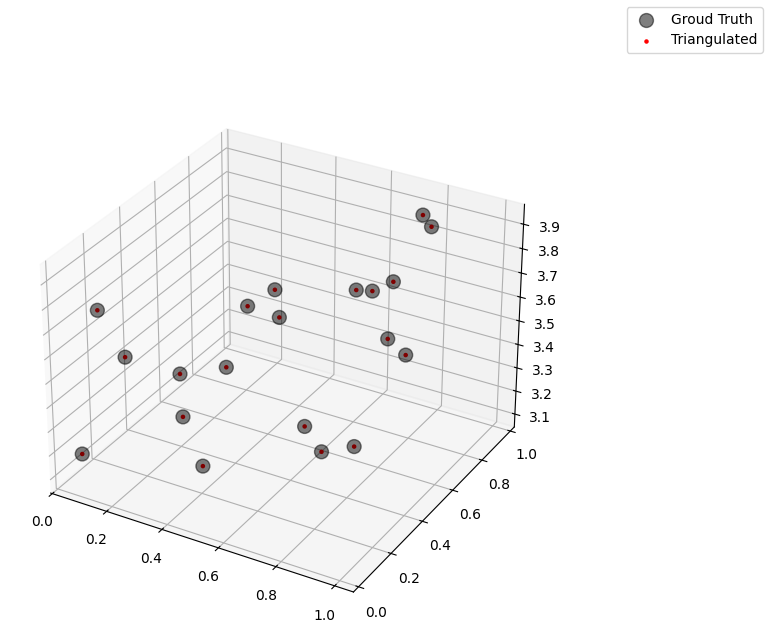

In [10]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(projection='3d')
utils.draw_points(X_eucl.T, ax=ax, c="k", alpha=0.5, s=100, depthshade=True, label="Groud Truth")
utils.draw_points(X_eucl_pred.T, ax=ax, c="r", alpha=1, s=5, depthshade=True, label="Triangulated")
fig.legend()

In [11]:
fig = go.Figure(layout=dict(height=400, width=550))
fig.add_trace(go.Scatter3d(x=X_eucl[0,:], y=X_eucl[1,:], z=X_eucl[2,:], mode='markers', marker=dict(size=6, color="black", opacity=0.5), name='Ground Truth'))
fig.add_trace(go.Scatter3d(x=X_eucl_pred[0,:], y=X_eucl_pred[1,:], z=X_eucl_pred[2,:], mode='markers', marker=dict(size=2, color="red", opacity=1), name='Triangulated'))
fig.show()

## **3. Reconstruction from two views**

The goal of this section is to estimate the 3D reconstruction from two views in a practical situation where the image correspondences contain outliers. 

To acomplish this you have to:

1. Find a set of point correspondences between the two images. This correspondences will contain noise/outliers, therefore we cannot use [Epipolar Geometry](https://www.cs.cmu.edu/~16385/s17/Slides/12.1_Epipolar_Geometry.pdf) to calculate the [Essential Matrix](https://www.cs.cmu.edu/~16385/s17/Slides/12.2_Essential_Matrix.pdf), but we can find the Fundamental Matrix. 
2. Estimate the [Fundamental Matrix](https://www.cs.cmu.edu/~16385/s17/Slides/12.3_Fundamental_Matrix.pdf) relating the two camera images. Since correspondances are noisy we will use the [8-point Algorithm](https://www.cs.cmu.edu/~16385/s17/Slides/12.4_8Point_Algorithm.pdf) in combination with the RANSAC algorithm, to find a good estimate of $F$.
3. Calculate the Essential Matrix from the Fundamental Matrix
4. Find the two Camera Matrices.
### **3.1 Estimate the image matches**
(Code is provided)

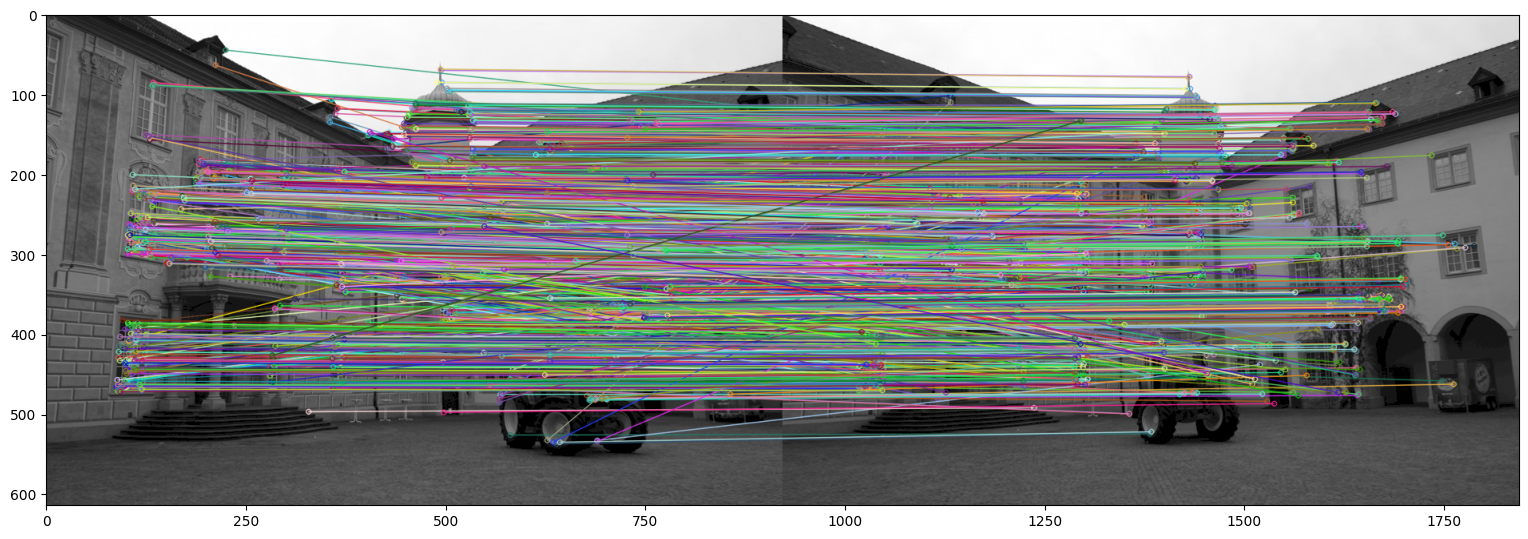

In [12]:
# Read images
img1 = cv2.imread('Data/0001_s.png',cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('Data/0002_s.png',cv2.IMREAD_GRAYSCALE)
h, w = img1.shape

# Initiate ORB detector
orb = cv2.ORB_create(3000)
# find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(img1,None)
kp2, des2 = orb.detectAndCompute(img2,None)

# Keypoint matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1,des2)

# Show "good" matches
img_12 = cv2.drawMatches(img1,kp1,img2,kp2,matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
fig = plt.figure()
plt.imshow(img_12)
plt.show()

### **3.2 Estimate the Fundamental Matrix**
To find the Fundamental Matrix $F$ we will use the 8-point algorithm. However, using only 8 correspondences might lead to bad estimates of $F$. To find a robust estimate we will use the RANSAC algorithm. In simple words the algorithm samples randomly 8 correspondences and estimates $F_{estimated}$ for these samples, then it evaluates how well does $F_{estimated}$ fit the rest of the data. We repeat this process until a limit of iterations is reached and select the best estimated $F$.  

(Code is provided)

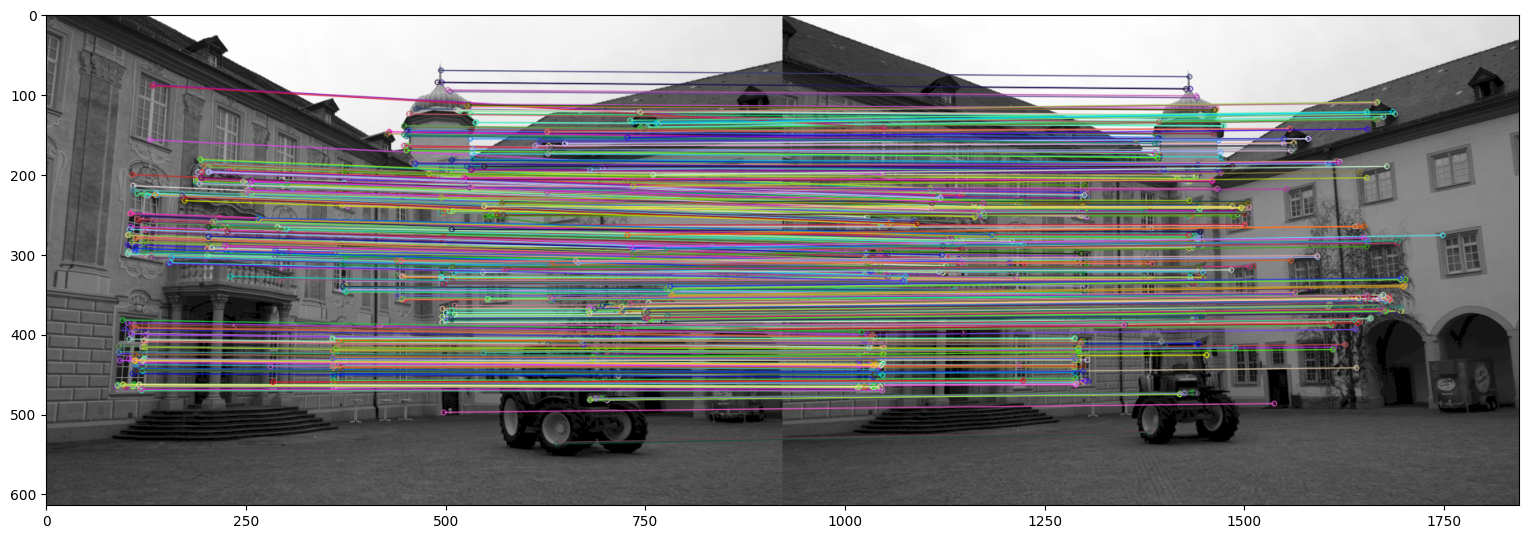

In [13]:
# Robust estimation of the fundamental matrix #
points1 = []
points2 = []
for m in matches:
    points1.append([kp1[m.queryIdx].pt[0], kp1[m.queryIdx].pt[1], 1])
    points2.append([kp2[m.trainIdx].pt[0], kp2[m.trainIdx].pt[1], 1])
    
points1 = np.asarray(points1)
points1 = points1.T
points2 = np.asarray(points2)
points2 = points2.T

F, indices_inlier_matches = Ransac_fundamental_matrix(points1, points2, 1, 5000)
inlier_matches = itemgetter(*indices_inlier_matches)(matches)

img_12 = cv2.drawMatches(img1,kp1,img2,kp2,inlier_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
fig = plt.figure()
plt.imshow(img_12)
plt.show()

### **3.3 Estimate the Essential Matrix**
<span style='color:Green'> - Compute the [Essential matrix](https://www.cs.cmu.edu/~16385/s17/Slides/12.2_Essential_Matrix.pdf) from the Fundamental matrix </span>

#### Explanation

**Theory:** Since the Fundamental matrix can be computed from the Essential matrix given equation $F = K^{-T}EK^{-1}$, to get the Essential matrix we just need to isolate is by passing the intrinsic camera matrices to the other side, obtaining the equation $E = K^{T}FK$. This makes perfect sense as we are adding the calibrated information (intrinsic matrices K) to the uncalibrated spatial information (matrix F).  

**Implementation notes:** We just implement this as a simple matrix multiplication.

In [14]:
# Camera calibration matrix
K = np.array([[2362.12, 0, 1520.69], [0, 2366.12, 1006.81], [0, 0, 1]])
scale = 0.3;
H = np.array([[scale, 0, 0], [ 0, scale, 0], [0, 0, 1]])
K = H @ K;

def essential_from_fundamental(K, F):
    # Fundamental matrix F = K^-T @ E @ K^-1
    # Essential matris E =  K^T F @ K
    return K.T @ F @ K
    raise NotImplementedError()

E = essential_from_fundamental(K, F)

### **3.4. Estimate the Camera Matrices from the Essential Matrix (Optional)**
<span style='color:Green'> - Estimate the camera projection matrices. Assuming the first Camera has a cannonical matrix you will obtain four possible Camera Matrices for the second camera, two rotations and two translations.</span>

 - Please explain how do you obtain these estimates, not what algorithm or methodology you used to obtain them. i.e., What system of equations are you solving?
 - Why do you obtain 4 solutions? Why not only one?

HINT: Once you estimate the rotations $R$ and translation $T$ of the second camera matrix, you may get as results improper rotations: $|R| = -1$ i.e., $R \in O(3), R \notin SO(3)$. <span style='color:Green'> (Why do you think this happens?) </span> In that case you should make the rotation proper by avoiding the unwanted reflexion (multiply by -1 so $|R| = 1$): e.g.,
  
      if det(R) < 0:  
          R = -R

In [15]:
P1 = np.zeros((3,4))
P1[0,0]=P1[1,1]=P1[2,2]=1                            # Cam1 Canonical Camera Matrix

# Extract the four possible camera matrices from Essential matrix E
# First, perform SVD on E
U, S, Vt = np.linalg.svd(E)

# Define the W matrix for rotation extraction
W = np.array([[0, -1, 0],
              [1,  0, 0],
              [0,  0, 1]])

# Extract two possible rotations
R1 = U @ W @ Vt
R2 = U @ W.T @ Vt

# Ensure proper rotations (det = 1, not -1)
if np.linalg.det(R1) < 0:
    R1 = -R1
if np.linalg.det(R2) < 0:
    R2 = -R2

# Extract translation (up to scale)
t = U[:, 2]  # Last column of U

# Four possible camera matrices
Pc2 = [None, None, None, None]
Pc2[0] = K @ np.hstack([R1, t.reshape(3, 1)])       # R1, +t
Pc2[1] = K @ np.hstack([R1, -t.reshape(3, 1)])      # R1, -t
Pc2[2] = K @ np.hstack([R2, t.reshape(3, 1)])       # R2, +t
Pc2[3] = K @ np.hstack([R2, -t.reshape(3, 1)])      # R2, -t

# Also need to define P1 with calibration
P1 = K @ P1

print("Four possible camera matrices computed from Essential matrix")
print(f"P1 (Camera 1 - Canonical): shape {P1.shape}")
for i, P in enumerate(Pc2):
    print(f"Pc2[{i}]: shape {P.shape}, det(R) = {np.linalg.det(P[:, :3] @ np.linalg.inv(K)):.3f}")


Four possible camera matrices computed from Essential matrix
P1 (Camera 1 - Canonical): shape (3, 4)
Pc2[0]: shape (3, 4), det(R) = 1.000
Pc2[1]: shape (3, 4), det(R) = 1.000
Pc2[2]: shape (3, 4), det(R) = 1.000
Pc2[3]: shape (3, 4), det(R) = 1.000


Lets visualize the 4 possible Camera positions and orientations, in relation to Camera 1 

(-1.5, 1.5)

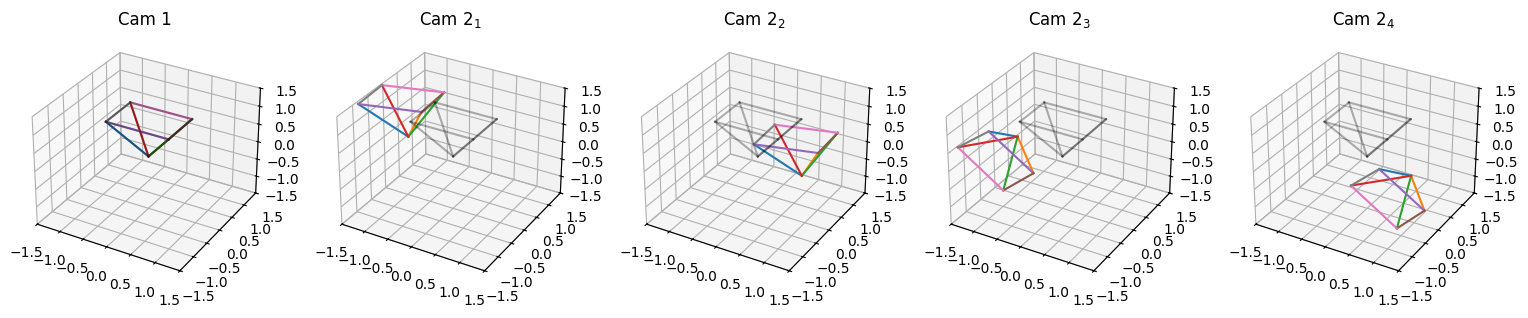

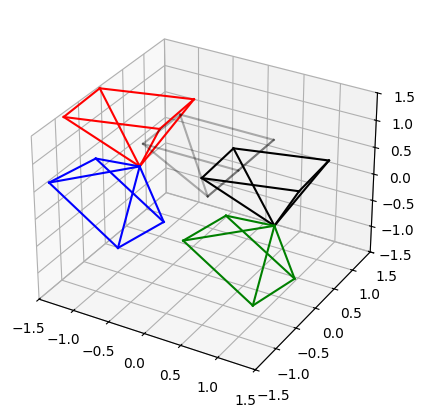

In [16]:
# plot the first camera and the four possible solutions for the second figure:
fig = plt.figure()
axs = [fig.add_subplot(1,5,i+1, projection='3d') for i in range(5)]
titles = ["Cam 1"] + [r"Cam $2_{%s}$" % int(i+1) for i in range(len(Pc2)) ]

low_lim, up_lim = -1.5, 1.5
for ax, title, P in zip(axs, titles, [P1] + Pc2):
    utils.plot_camera(P,w,h, 1, ax=ax)
    utils.plot_camera(P1,w,h, 1, ax=ax, alpha=0.3, color="k") # Show Cam1 for reference
    ax.set_title(title)
    ax.set_xlim(low_lim, up_lim)
    ax.set_ylim(low_lim, up_lim)
    ax.set_zlim(low_lim, up_lim)
    
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1, projection='3d')
for P, color in zip(Pc2, ['r','k','b','g']):
    utils.plot_camera(P,w,h, 1, ax=ax, color=color)
utils.plot_camera(P1,w,h, 1, ax=ax, alpha=0.3, color="k") # Show Cam1 for reference
ax.set_xlim(low_lim, up_lim)
ax.set_ylim(low_lim, up_lim)
ax.set_zlim(low_lim, up_lim)

<span style='color:Green'> - Triangulate the correspondences and select the "optimal" camera, how do you select it ?</span>
   


Camera Selection Process


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 4)

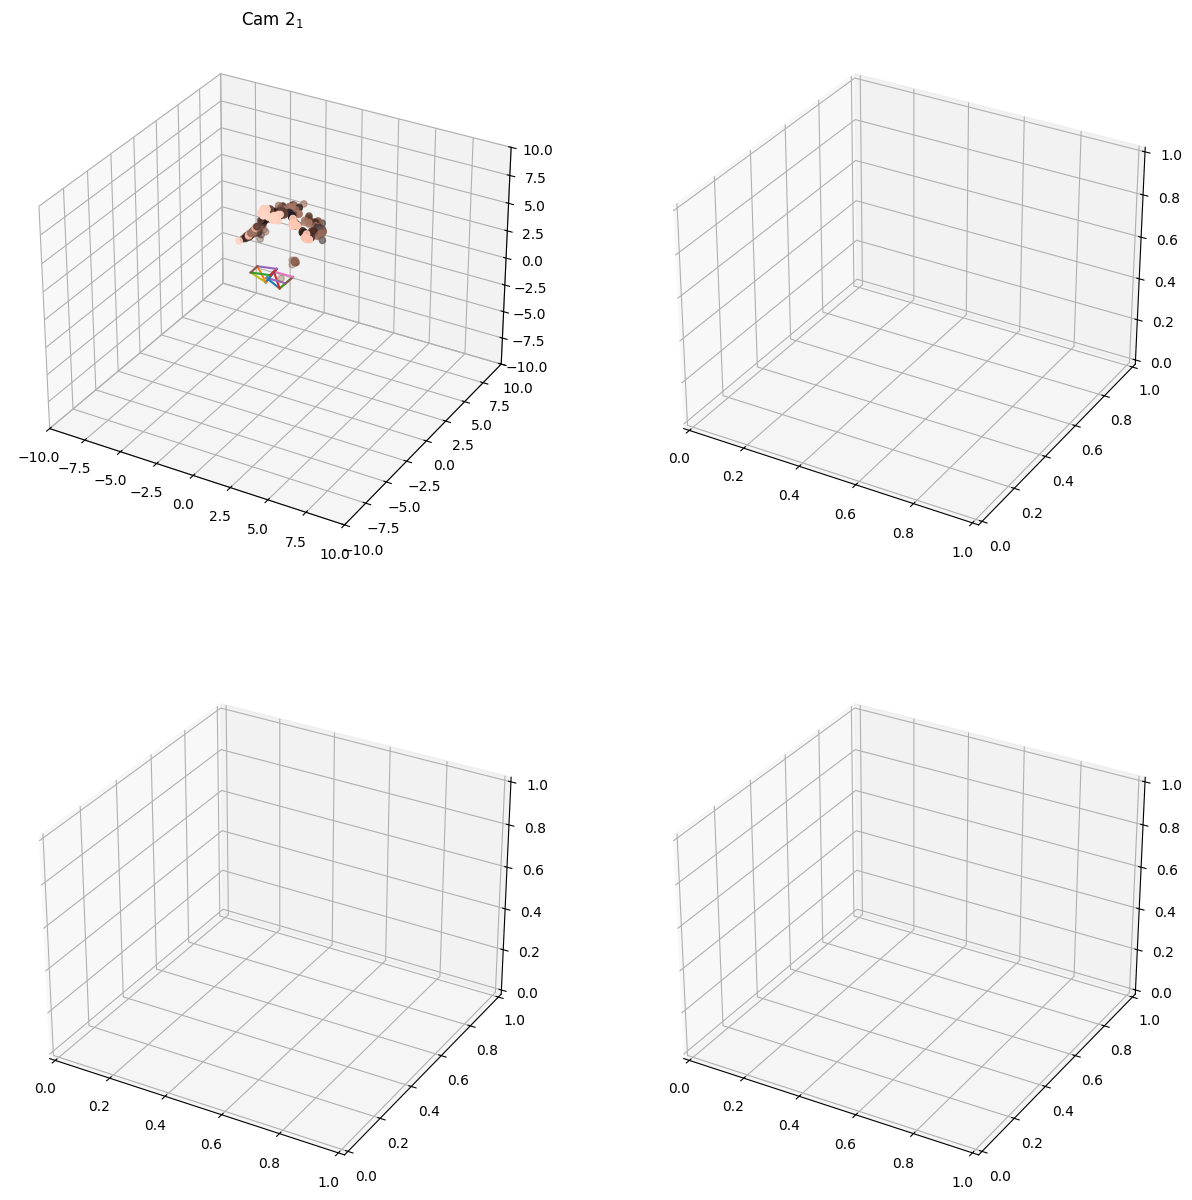

In [18]:
img1 = cv2.imread('Data/0000_s.png', cv2.IMREAD_UNCHANGED)

# Obtain the inlier points projective coordinates for Camera 1 and 2
# Extract inlier correspondences from RANSAC
x1_inl = points1[:, indices_inlier_matches]  # Shape: (3, n_inliers)
x2_inl = points2[:, indices_inlier_matches]  # Shape: (3, n_inliers)

x1 = x1_inl
x2 = x2_inl

# Prepare figure
fig = plt.figure(figsize=(15, 15))
axs = [fig.add_subplot(2, 2, i+1, projection='3d') for i in range(4)]

# Variable for optimal camera
P2_selected = None
best_score = -np.inf

low_lim, up_lim = -10, 10

print("\nCamera Selection Process")
for i, ax, P2 in zip(range(len(Pc2)), axs, Pc2):
    # Estimate by triangulation the 3D coordinates of the matches
    X_pred = triangulate(x1, x2, P1, P2, [w, h])
    X_eucl = homogeneous2euclidean(X_pred)
    
    # Render the 3D point cloud
    x_img = np.transpose(x1[:2]).astype(int)
    rgb_txt = (img1[x_img[:, 1], x_img[:, 0]]) / 255
    utils.draw_points(X_eucl.T, color=rgb_txt, ax=ax)
    utils.plot_camera(P1, w, h, 1, ax=ax)
    utils.plot_camera(P2, w, h, 1, ax=ax)
    ax.set_title(r"Cam $2_{%d}$" % (i+1))
    ax.set_xlim(low_lim, up_lim)
    ax.set_ylim(low_lim, up_lim)
    ax.set_zlim(low_lim, up_lim)
    
    # Select the best camera using cheirality constraint
    # Points must be in front of BOTH cameras (positive depth)
    
    # Check depth in camera 1
    depths_cam1 = X_pred[2, :]  # Z coordinate in homogeneous (before normalization)
    
    # Check depth in camera 2
    # Transform points to camera 2 coordinate system
    P2_normalized = P2 @ np.linalg.inv(K)  # Remove intrinsics to get [R|t]
    X_cam2 = P2_normalized @ X_pred  # Project to camera 2
    depths_cam2 = X_cam2[2, :]
    
    # Count how many points are in front of both cameras
    in_front_cam1 = np.sum(depths_cam1 > 0)
    in_front_cam2 = np.sum(depths_cam2 > 0)
    both_positive = np.sum((depths_cam1 > 0) & (depths_cam2 > 0))
    
    # Score is the number of points with positive depth in both cameras
    score = both_positive
    
    print(f"\nCamera {i+1}:")
    print(f"  Points in front of Cam1: {in_front_cam1}/{len(depths_cam1)}")
    print(f"  Points in front of Cam2: {in_front_cam2}/{len(depths_cam2)}")
    print(f"  Points in front of BOTH: {both_positive}/{len(depths_cam1)}")
    print(f"  Score: {score}")
    
    # Select camera with maximum number of points in front of both cameras
    if score > best_score:
        best_score = score
        P2_selected = P2
        best_idx = i

print(f"\n=== Selected Camera 2_{best_idx+1} with score {best_score} ===")
print("Selection criterion: Maximum number of points with positive depth in both cameras")
print("This is the cheirality constraint - points must be visible from both viewpoints")

# From now on P2 will be the camera you selected
P2 = P2_selected

plt.tight_layout()
plt.show()

### **3.5 3D Visualization (Optiona, provided)**
 We will visualize the 3D points for the selected camera with an interactive plot so that you can see the surfaces reconstructed in 3D

In [ ]:
# Estimate by triangulization the 3D coordinates of the matches
X_pred = triangulate(x1, x2, P1, P2, [w, h])
X_eucl = X_pred/X_pred[-1,:]
points3d = X_eucl[:3].T
fig = go.Figure(layout=dict(height=400, width=550))
points3d = X_eucl[:3].T
fig.add_trace(go.Scatter3d(x=points3d[:,0], y=points3d[:,1], z=points3d[:,2],mode='markers',name='3d points',marker=dict(color=rgb_txt, size=2)))
fig.show()

In [ ]:
X_pred = triangulate(x1, x2, P1, P2, [w, h])
X_eucl = X_pred / X_pred[-1, :]
points3d = X_eucl[:3].T

fig = go.Figure(layout=dict(height=800, width=1000))
fig.add_trace(go.Scatter3d(
    x=points3d[:, 0], 
    y=points3d[:, 1], 
    z=points3d[:, 2],
    mode='markers',
    name='3D points',
    marker=dict(color=rgb_txt, size=2)
))

fig.update_layout(
    title="3D Reconstruction from Two Views",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode='data'
    )
)

fig.show()

In [ ]:
img_with_selected_points = copy.deepcopy(img1)
img_with_selected_points[x_img[:, 1], x_img[:, 0]] = [255, 0, 0]
plt.figure(figsize=(80, 40))
plt.imshow(img_with_selected_points)
plt.title("Inlier correspondences used for reconstruction")
plt.show()

In [ ]:
# Estimate by triangulization the 3D coordinates of the matches
X_pred = triangulate(x1, x2, P1, P2, [w, h])
X_eucl = X_pred/X_pred[-1,:]
points3d = X_eucl[:3].T
fig = go.Figure(layout=dict(height=400, width=550))
points3d = X_eucl[:3].T
fig.add_trace(go.Scatter3d(x=points3d[:,0], y=points3d[:,1], z=points3d[:,2],mode='markers',name='3d points',marker=dict(color=rgb_txt, size=2)))
fig.show()
# Estimate by triangulization the 3D coordinates of the matches
X_pred = triangulate(x1, x2, P1, P2, [w, h])
X_eucl = X_pred/X_pred[-1,:]
points3d = X_eucl[:3].T
fig = go.Figure(layout=dict(height=400, width=550))
points3d = X_eucl[:3].T
fig.add_trace(go.Scatter3d(x=points3d[:,0], y=points3d[:,1], z=points3d[:,2],mode='markers',name='3d points',marker=dict(color=rgb_txt, size=2)))
fig.show()
# Estimate by triangulization the 3D coordinates of the matches
X_pred = triangulate(x1, x2, P1, P2, [w, h])
X_eucl = X_pred/X_pred[-1,:]
points3d = X_eucl[:3].T
fig = go.Figure(layout=dict(height=400, width=550))
points3d = X_eucl[:3].T
fig.add_trace(go.Scatter3d(x=points3d[:,0], y=points3d[:,1], z=points3d[:,2],mode='markers',name='3d points',marker=dict(color=rgb_txt, size=2)))
fig.show()
#### And these are the corresponding points in 2D 

In [ ]:
img_with_selected_points = copy.deepcopy(img1)
img_with_selected_points[x_img[:,1], x_img[:,0]] = [255,0,0]
plt.figure(figsize = (80,40))
plt.imshow(img_with_selected_points)

### **3.6 Reprojection Error (Optional)**

Once you selected a Camera, analyze the error of reprojecting the 3D space back to image coordinates. 

<span style='color:Green'>- Compute the reprojection errors  </span>

<span style='color:Green'>- Plot the histogram of reprojection errors, </span>

<span style='color:Green'>- Plot the mean reprojection error  </span>

In [ ]:
def reprojection_errors(x1, x2, P1, P2, X):
    """
    Compute reprojection errors for triangulated 3D points
    
    Parameters:
    - x1: (3, n_points) projective coordinates in Camera 1
    - x2: (3, n_points) projective coordinates in Camera 2
    - P1: (3, 4) Camera 1 projection matrix
    - P2: (3, 4) Camera 2 projection matrix
    - X: (4, n_points) homogeneous 3D coordinates
    
    Returns:
    - cam1_errors: (n_points,) reprojection errors for camera 1
    - cam2_errors: (n_points,) reprojection errors for camera 2
    """
    
    # Project 3D points back to camera 1
    x1_proj = P1 @ X  # Shape: (3, n_points)
    # Convert to image coordinates (normalize by third coordinate)
    x1_proj_img = x1_proj[:2, :] / x1_proj[2, :]  # Shape: (2, n_points)
    
    # Project 3D points back to camera 2
    x2_proj = P2 @ X  # Shape: (3, n_points)
    # Convert to image coordinates (normalize by third coordinate)
    x2_proj_img = x2_proj[:2, :] / x2_proj[2, :]  # Shape: (2, n_points)
    
    # Get original image coordinates
    x1_img = x1[:2, :] / x1[2, :]  # Shape: (2, n_points)
    x2_img = x2[:2, :] / x2[2, :]  # Shape: (2, n_points)
    
    # Compute Euclidean distance (L2 norm) between projected and original points
    cam1_errors = np.sqrt(np.sum((x1_proj_img - x1_img)**2, axis=0))  # Shape: (n_points,)
    cam2_errors = np.sqrt(np.sum((x2_proj_img - x2_img)**2, axis=0))  # Shape: (n_points,)
    
    return cam1_errors, cam2_errors


def plot_error_stats(cam1_errors, cam2_errors):
    """
    Plot histograms and statistics of reprojection errors
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    
    # Camera 1 histogram
    ax1.hist(cam1_errors, bins=30, color='c', edgecolor='black', alpha=0.7)
    ax1.grid(axis='y', alpha=0.2)
    ax1.set_xlabel("Reprojection Error [pixels]")
    ax1.set_ylabel("Frequency")
    ax1.set_title(f"Camera 1 - Mean: {np.mean(cam1_errors):.3f} px, "
                  f"Median: {np.median(cam1_errors):.3f} px")
    ax1.axvline(np.mean(cam1_errors), color='r', linestyle='--', 
                linewidth=2, label=f'Mean = {np.mean(cam1_errors):.3f} px')
    ax1.legend()
    
    # Camera 2 histogram
    ax2.hist(cam2_errors, bins=30, color='k', edgecolor='black', alpha=0.7)
    ax2.grid(axis='y', alpha=0.2)
    ax2.set_xlabel("Reprojection Error [pixels]")
    ax2.set_ylabel("Frequency")
    ax2.set_title(f"Camera 2 - Mean: {np.mean(cam2_errors):.3f} px, "
                  f"Median: {np.median(cam2_errors):.3f} px")
    ax2.axvline(np.mean(cam2_errors), color='r', linestyle='--', 
                linewidth=2, label=f'Mean = {np.mean(cam2_errors):.3f} px')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


# Get projections with selected Camera
X_pred = triangulate(x1, x2, P1, P2, [w, h])

# Compute reprojection errors
cam1_errors, cam2_errors = reprojection_errors(x1, x2, P1, P2, X_pred)

# Plot error statistics
plot_error_stats(cam1_errors, cam2_errors)

# Print detailed statistics
print("\n" + "="*60)
print("           REPROJECTION ERROR STATISTICS")
print("="*60)

print("\nCamera 1:")
print(f"  Mean error:       {np.mean(cam1_errors):8.4f} pixels")
print(f"  Median error:     {np.median(cam1_errors):8.4f} pixels")
print(f"  Std deviation:    {np.std(cam1_errors):8.4f} pixels")
print(f"  Min error:        {np.min(cam1_errors):8.4f} pixels")
print(f"  Max error:        {np.max(cam1_errors):8.4f} pixels")
print(f"  95th percentile:  {np.percentile(cam1_errors, 95):8.4f} pixels")

print("\nCamera 2:")
print(f"  Mean error:       {np.mean(cam2_errors):8.4f} pixels")
print(f"  Median error:     {np.median(cam2_errors):8.4f} pixels")
print(f"  Std deviation:    {np.std(cam2_errors):8.4f} pixels")
print(f"  Min error:        {np.min(cam2_errors):8.4f} pixels")
print(f"  Max error:        {np.max(cam2_errors):8.4f} pixels")
print(f"  95th percentile:  {np.percentile(cam2_errors, 95):8.4f} pixels")

print("\nOverall Statistics:")
overall_mean = (np.mean(cam1_errors) + np.mean(cam2_errors)) / 2
print(f"  Mean reprojection error:  {overall_mean:8.4f} pixels")
print(f"  Total points:             {len(cam1_errors)}")

print("\n" + "="*60)
print("Interpretation:")
print("- Errors are in pixel units")
print("- Good reconstruction typically has mean error < 1-2 pixels")
print("- Large errors may indicate outliers or poor camera estimation")
print("="*60 + "\n")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Camera 1 error visualization
x1_img_coords = (x1[:2, :] / x1[2, :]).T.astype(int)
scatter1 = ax1.scatter(x1_img_coords[:, 0], x1_img_coords[:, 1], 
                       c=cam1_errors, cmap='hot', s=50, alpha=0.7)
ax1.set_title("Camera 1 - Spatial Distribution of Reprojection Errors")
ax1.set_xlabel("X coordinate [pixels]")
ax1.set_ylabel("Y coordinate [pixels]")
ax1.invert_yaxis()
plt.colorbar(scatter1, ax=ax1, label='Error [pixels]')

# Camera 2 error visualization
x2_img_coords = (x2[:2, :] / x2[2, :]).T.astype(int)
scatter2 = ax2.scatter(x2_img_coords[:, 0], x2_img_coords[:, 1], 
                       c=cam2_errors, cmap='hot', s=50, alpha=0.7)
ax2.set_title("Camera 2 - Spatial Distribution of Reprojection Errors")
ax2.set_xlabel("X coordinate [pixels]")
ax2.set_ylabel("Y coordinate [pixels]")
ax2.invert_yaxis()
plt.colorbar(scatter2, ax=ax2, label='Error [pixels]')

plt.tight_layout()
plt.show()

print("Spatial error visualization complete!")
print("Hot colors (red/yellow) indicate larger reprojection errors")
print("Cool colors (dark) indicate smaller errors")
